# 02 — Exploratory Data Analysis & Preprocessing

Loads the merged NHANES dataset, engineers features + RMR target, runs the full preprocessing pipeline, and produces publication-quality EDA figures (saved to `../outputs/figures/`, 300 DPI).

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from data_loader import load_config
from feature_engineering import engineer_all_features
from preprocess import run_full_preprocessing

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 300
config = load_config('../config.yaml')
np.random.seed(config['random_seed'])

In [2]:
df_raw = pd.read_csv(config['paths']['merged_csv'])
df = engineer_all_features(df_raw, config)
df.shape

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/nhanes_merged_2017_2018.csv'

## Target distribution: RMR

NameError: name 'df' is not defined

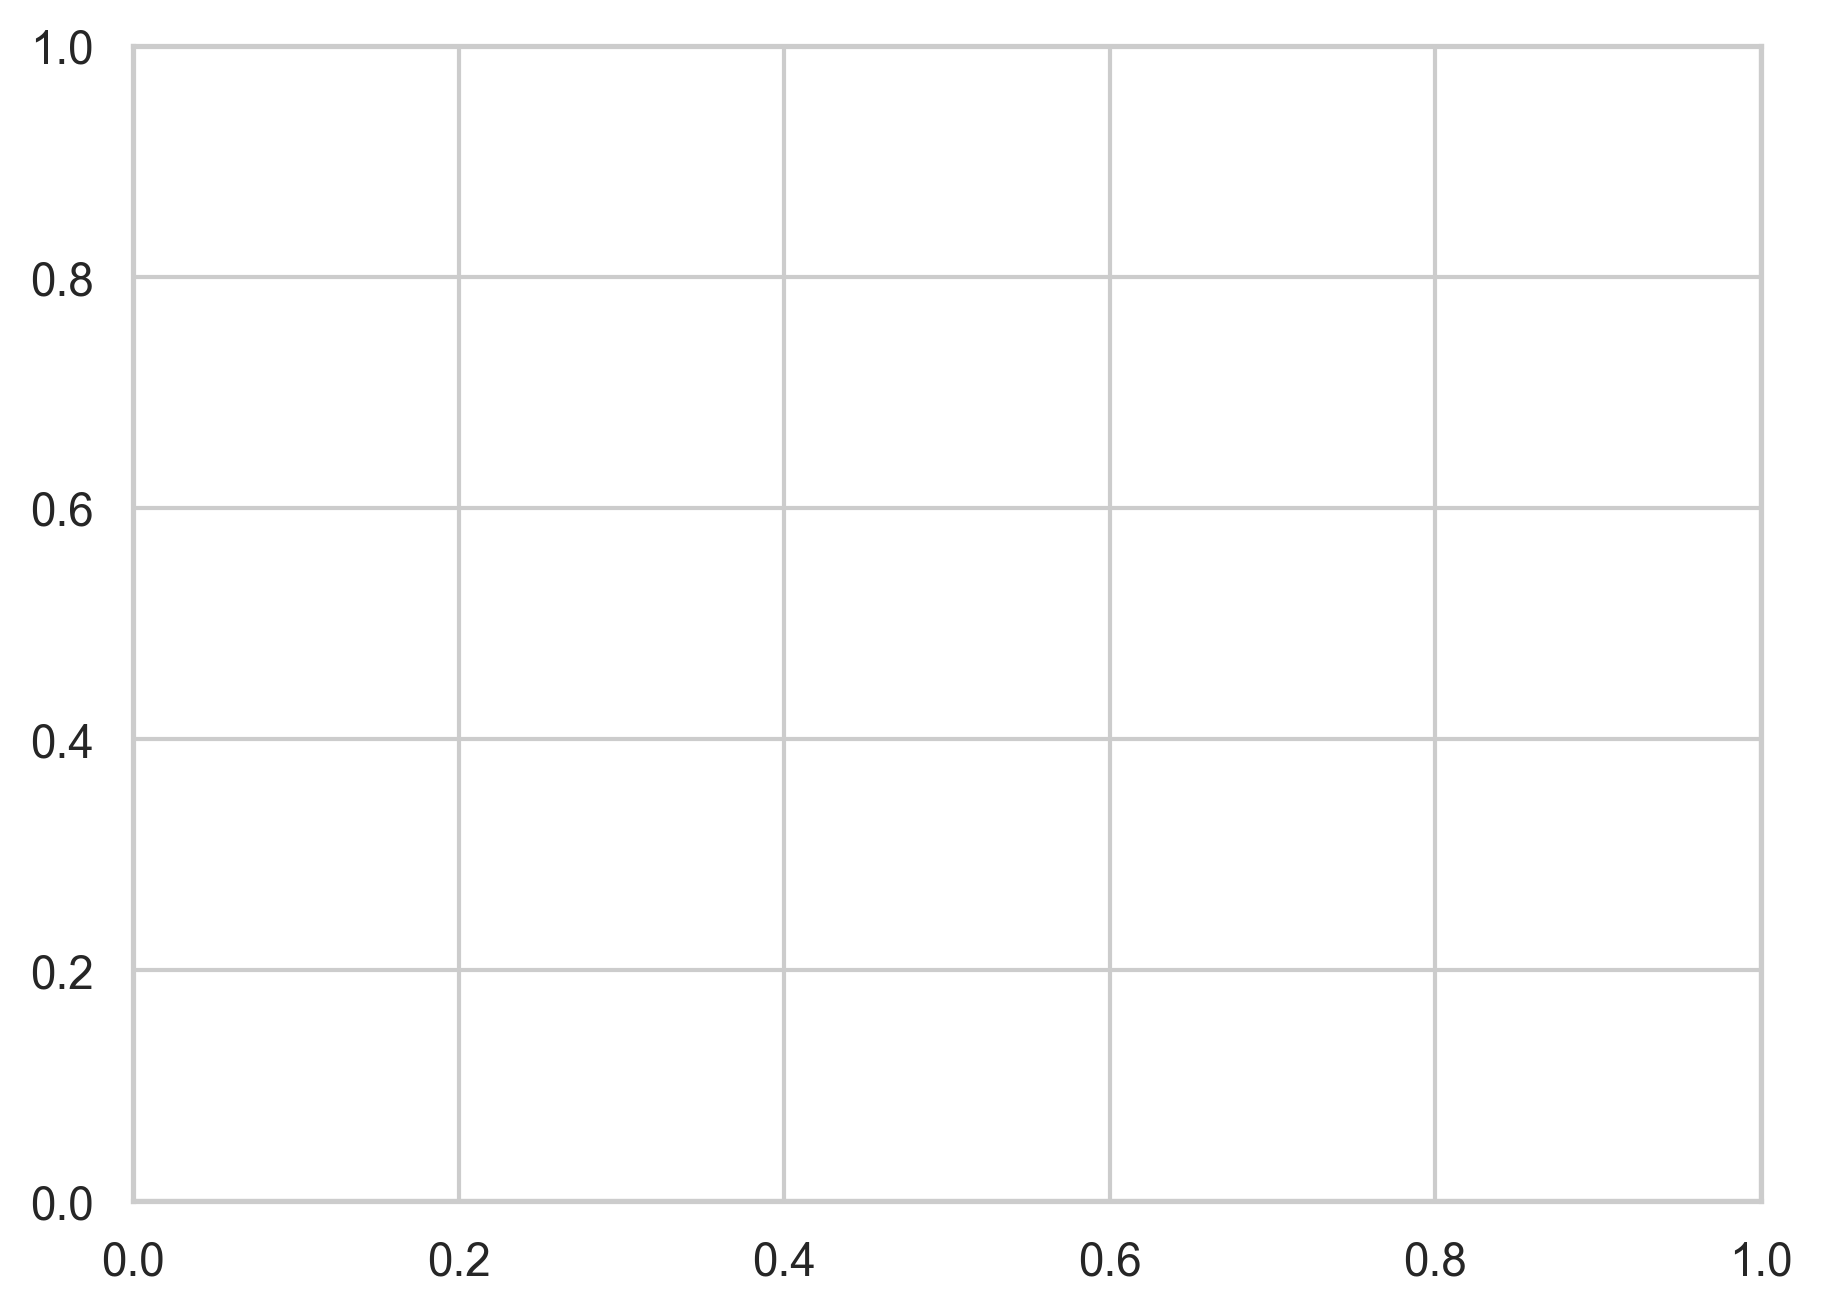

In [3]:
fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(df['RMR_kcal_day'].dropna(), kde=True, ax=ax, color='#1a5276')
ax.set_xlabel('Predicted RMR (kcal/day)'); ax.set_ylabel('Count')
ax.set_title('Distribution of Mifflin-St Jeor RMR (NHANES 2017-2018)')
fig.tight_layout(); fig.savefig('../outputs/figures/rmr_distribution.png', dpi=300)

## Feature distributions

In [ ]:
numeric_cols = ['RIDAGEYR','BMXBMI','BMXWAIST','LBXGLU','LBXGH','LBDHDD','LBXTR']
fig, axes = plt.subplots(2, 4, figsize=(20,8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
fig.tight_layout(); fig.savefig('../outputs/figures/feature_distributions.png', dpi=300)

## Correlation heatmap

In [ ]:
corr_cols = numeric_cols + ['RMR_kcal_day']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
fig.tight_layout(); fig.savefig('../outputs/figures/correlation_heatmap.png', dpi=300)

## Age vs RMR

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.regplot(data=df, x='RIDAGEYR', y='RMR_kcal_day', scatter_kws={'alpha':0.3}, ax=ax)
ax.set_title('Age vs Predicted RMR')
fig.tight_layout(); fig.savefig('../outputs/figures/age_vs_rmr.png', dpi=300)

## BMI vs RMR

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.regplot(data=df, x='BMXBMI', y='RMR_kcal_day', scatter_kws={'alpha':0.3}, color='seagreen', ax=ax)
ax.set_title('BMI vs Predicted RMR')
fig.tight_layout(); fig.savefig('../outputs/figures/bmi_vs_rmr.png', dpi=300)

## Physical activity vs RMR

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x='Physical_Activity_Category', y='RMR_kcal_day', ax=ax,
            order=['Sedentary','Moderate','Vigorous'])
ax.set_title('Physical Activity Category vs Predicted RMR')
fig.tight_layout(); fig.savefig('../outputs/figures/activity_vs_rmr.png', dpi=300)

## Glucose & HbA1c vs RMR

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.scatterplot(data=df, x='LBXGLU', y='RMR_kcal_day', alpha=0.3, ax=axes[0])
axes[0].set_title('Fasting Glucose vs RMR')
sns.scatterplot(data=df, x='LBXGH', y='RMR_kcal_day', alpha=0.3, ax=axes[1])
axes[1].set_title('HbA1c vs RMR')
fig.tight_layout(); fig.savefig('../outputs/figures/glucose_hba1c_vs_rmr.png', dpi=300)

## Sex differences in RMR

In [ ]:
df['_sex_label'] = df['RIAGENDR'].map({1:'Male', 2:'Female'})
fig, ax = plt.subplots(figsize=(7,5))
sns.violinplot(data=df, x='_sex_label', y='RMR_kcal_day', ax=ax)
ax.set_title('Sex Differences in Predicted RMR')
fig.tight_layout(); fig.savefig('../outputs/figures/sex_vs_rmr.png', dpi=300)

## Run full preprocessing pipeline

In [ ]:
splits = run_full_preprocessing(df.drop(columns=['_sex_label']), 'RMR_kcal_day', config)
splits['vif_table'].head(10)

In [ ]:
import joblib
joblib.dump(splits, '../data/processed/splits.pkl')
print('Saved processed splits to ../data/processed/splits.pkl')